# Distance-3 Surface Code Simulator

This notebook demonstrates the usage of the `qec` package.

Features:
- Distance-3 planar surface code
- Syndrome extraction
- MWPM decoding
- Space-time decoding
- Depolarising and readout noise models

The implementation lives in `src/qec/`.

In [1]:
# Import dependencies

import sys
from pathlib import Path
from qiskit import transpile
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from qec.noise import depol_noise_model
from qec.circuit import one_round_surface_code
from qec.simulation import compare_single_vs_spacetime
from qec.visualization import plot_decoder_comparison


## Single-round syndrome extraction

In [3]:
sim = AerSimulator()
basis = ['id','rz','sx','x','h','cx','measure']

qc = one_round_surface_code()
tc = transpile(qc, sim, basis_gates=basis, optimization_level=1)

noise = depol_noise_model(p1=0.01, ro=0.01)   # tweak p1 to see more/less defects
res = sim.run(tc, shots=2000, noise_model=noise).result()
counts = res.get_counts()

print("num distinct syndromes:", len(counts))
list(counts.items())[:5]

# quick parse: convert bitstring 'xxxxzzzz' -> (X_syndrome, Z_syndrome)
def parse_syndrome(bitstr, n_x=4):
    s = bitstr.replace(' ', '')  # just in case
    s = s[::-1]
    return s[:n_x], s[n_x:]

# show top-5 most common syndromes
top = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:5]
for bits, n in top:
    xs, zs = parse_syndrome(bits, 4)
    print(f"{bits:>10}  shots={n:4d}   X={xs}  Z={zs}")

num distinct syndromes: 256
  10011001  shots=  15   X=1001  Z=1001
  00011110  shots=  15   X=0111  Z=1000
  10000111  shots=  15   X=1110  Z=0001
  10110110  shots=  14   X=0110  Z=1101
  01001011  shots=  14   X=1101  Z=0010


c:\wzf\学习\qec-surface-code-sim\.venv\Lib\site-packages\qiskit\compiler\transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


## Compare Single-Round and Space-Time Decoding

Run a sweep over physical depolarising error rates and compare:

- Single-round decoding
- Multi-round space-time decoding

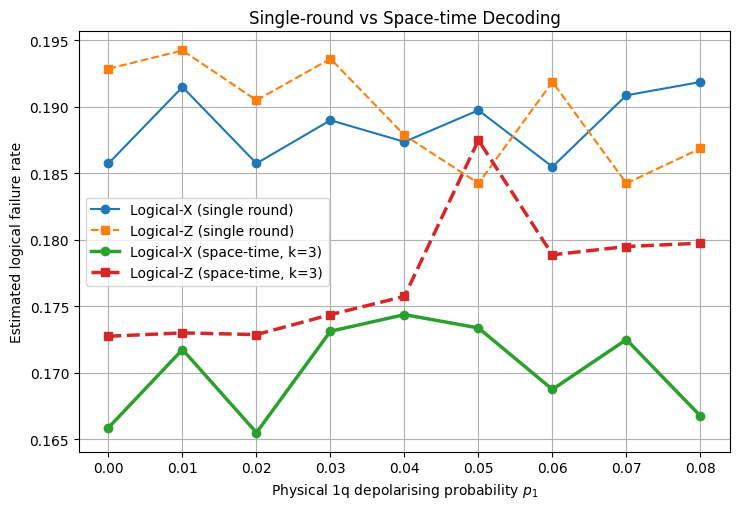

In [4]:
p_vals = np.linspace(0.0, 0.08, 9)

results = compare_single_vs_spacetime(
    p_vals,
    k_space_time=3,
    k_single=1,
    shots=8000,
    ro=0.01,
)

plot_decoder_comparison(
    *results,
)

## Configurable Code Distance

The simulator supports arbitrary odd code distances. The example below runs
a small Monte Carlo experiment for both d=3 and d=5 surface codes.

In [5]:
from qec.simulation import logical_failure_rates_single

for d in [3, 5]:
    fx, fz = logical_failure_rates_single(
        distance=d,
        shots=100,
        p1=0.01,
    )

    print(f"d={d}: logX={fx:.3f}, logZ={fz:.3f}")

d=3: logX=0.150, logZ=0.180
d=5: logX=0.130, logZ=0.240


## Results

The figure compares logical failure rates obtained using:

- Single-round MWPM decoding
- Space-time MWPM decoding

The current implementation demonstrates syndrome extraction and decoding workflows for a distance-3 surface code.

Future work:

- Distance-5 and distance-7 codes
- Threshold studies
- Stim integration
- PyMatching backend
- Improved logical observable tracking

In [3]:
from qec.stim_backend import SurfaceCodeStimBackend

backend = SurfaceCodeStimBackend(
    distance=3,
    rounds=1,
)

print(backend.build_circuit())

R 0 1 2 3 4 5 6 7 8 9 10 11 12 9 10 11 12
H 9
CX 9 0 9 1 9 3 9 4
H 9
M 9
CX 1 10 2 10 4 10 5 10
M 10
CX 3 11 4 11 6 11 7 11
M 11
H 12
CX 12 4 12 5 12 7 12 8
H 12
M 12 0 1 2 3 4 5 6 7 8
OBSERVABLE_INCLUDE(0) rec[-9] rec[-6] rec[-3]
OBSERVABLE_INCLUDE(1) rec[-9] rec[-8] rec[-7]


In [4]:
backend = SurfaceCodeStimBackend(
    distance=3,
    rounds=2,
    depolarizing_error=0,
    readout_error=0,
)

print(
    backend.build_circuit().detector_error_model(
        allow_gauge_detectors=True
    )
)

detector(0.5, 0.5, 1, 0) D0
detector(0.5, 1.5, 1, 1) D1
detector(1.5, 0.5, 1, 1) D2
detector(1.5, 1.5, 1, 0) D3
logical_observable L0
logical_observable L1


In [5]:
backend = SurfaceCodeStimBackend(
    distance=3,
    rounds=5,
    depolarizing_error=0.01,
    readout_error=0.01,
)

dem = backend.detector_error_model()

print(dem)

error(0.01976726037533896) D0
error(0.003344519141621982) D0 D1 D2 D3
error(0.003344519141621982) D0 D1 L1
error(0.003344519141621982) D0 D2 L0
error(0.003344519141621982) D0 D3
error(0.01) D0 D4
error(0.003344519141621982) D0 L0 L1
error(0.01327762875878954) D1
error(0.003344519141621982) D1 D2
error(0.003344519141621982) D1 D3
error(0.01) D1 D5
error(0.009966592219733637) D1 L1
error(0.01327762875878954) D2
error(0.003344519141621982) D2 D3
error(0.01) D2 D6
error(0.009966592219733637) D2 L0
error(0.02297955555555545) D3
error(0.01) D3 D7
error(0.009966592219733637) D4
error(0.003344519141621982) D4 D5 D6 D7
error(0.003344519141621982) D4 D5 L1
error(0.003344519141621982) D4 D6 L0
error(0.003344519141621982) D4 D7
error(0.01) D4 D8
error(0.003344519141621982) D4 L0 L1
error(0.003344519141621982) D5
error(0.003344519141621982) D5 D6
error(0.003344519141621982) D5 D7
error(0.01) D5 D9
error(0.009966592219733637) D5 L1
error(0.003344519141621982) D6
error(0.003344519141621982) D6 D7
err